In [1]:
from google.colab import drive
drive.mount('/content/drive')
%cd "/content/drive/MyDrive/Early-Sepsis-Detection"

Mounted at /content/drive
/content/drive/MyDrive/Early-Sepsis-Detection


# 04 — Missing Value Analysis (Deep Dive)
### Early Sepsis Detection — Phase 5

Builds on Phase 2's missingness report and Phase 4's measurement-frequency
observation (Lactate/WBC re-测 spike near hour 55-70, coincident with the
sepsis-positive group's rising trends seen in `03_exploratory_data_analysis.ipynb`).

This notebook formally tests: **is missingness itself associated with
sepsis status?** — using the RAW (pre-LOCF) long-format data, since LOCF
in Phase 3 already overwrote most of the "was this measured this hour"
signal.


In [2]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import config

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)


In [3]:
# Use the RAW long-format cache (pre-LOCF) so missingness reflects true
# "was this measured" signal, not carried-forward values.
raw_df = pd.read_parquet(config.INTERIM_LONG_PARQUET)

patient_label = raw_df.groupby(config.PATIENT_ID_COL)[config.TARGET_COL].max().rename("patient_sepsis")
raw_df = raw_df.merge(patient_label, on=config.PATIENT_ID_COL, how="left")
print("Raw shape:", raw_df.shape)


Raw shape: (1552210, 44)


## 1. Missing percentage per feature (recap, full dataset)

Already computed exactly in `01_data_understanding.ipynb` — reproduced here
from the same raw cache as a consistency check before the deeper analysis.


In [4]:
missing_pct = (raw_df.isna().mean() * 100).sort_values(ascending=False)
display(missing_pct.to_frame("missing_pct").head(15))


,missing_pct
Bilirubin_direct,99.807371
Fibrinogen,99.340167
TroponinI,99.047745
Bilirubin_total,98.509158
Alkalinephos,98.393194
AST,98.377604
Lactate,97.329872
PTT,97.055875
SaO2,96.549372
EtCO2,96.286843


## 2. Missing percentage per patient

**What?** For each patient, what fraction of all (variable, hour) cells are
missing across their whole ICU stay.

**Why?** A patient with a very short stay will look "more complete" than a
long-stay patient purely due to fewer denominator cells for rarely-ordered
labs — this is examined so any per-patient feature normalizes correctly.


count    40336.000000
mean        80.402093
std          4.951796
min         46.078431
25%         77.764706
50%         80.534759
75%         82.916145
max        100.000000
Name: pct_missing_per_patient, dtype: float64


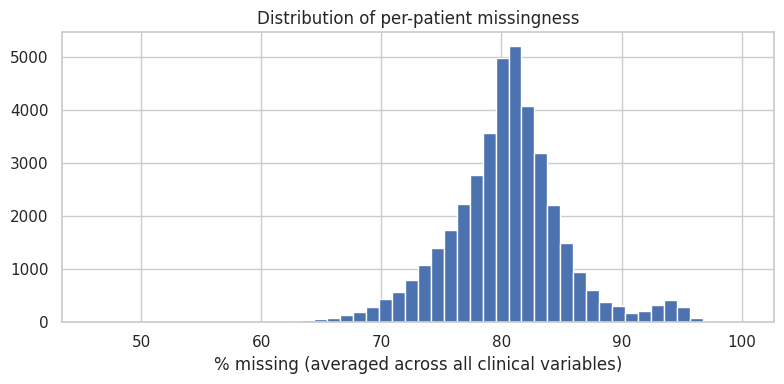

In [5]:
clinical_cols = config.ALL_CLINICAL_FEATURES
missing_per_patient = raw_df.groupby(config.PATIENT_ID_COL)[clinical_cols].apply(
    lambda g: g.isna().mean().mean() * 100
).rename("pct_missing_per_patient")

print(missing_per_patient.describe())

plt.figure(figsize=(8, 4))
missing_per_patient.hist(bins=50)
plt.xlabel("% missing (averaged across all clinical variables)")
plt.title("Distribution of per-patient missingness")
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "04_missingness_per_patient.png", dpi=150)
plt.show()


## 3. Missingness by ICU hour

**What?** Overall missing % across all clinical variables, by ICULOS.

**Why?** Complements Phase 4's per-variable measurement-frequency plots
with an aggregate view — helps spot whether early/late ICU hours are
systematically sparser (e.g. admission-hour data entry lag, or fewer
long-stay patients at high ICULOS thinning the denominator).


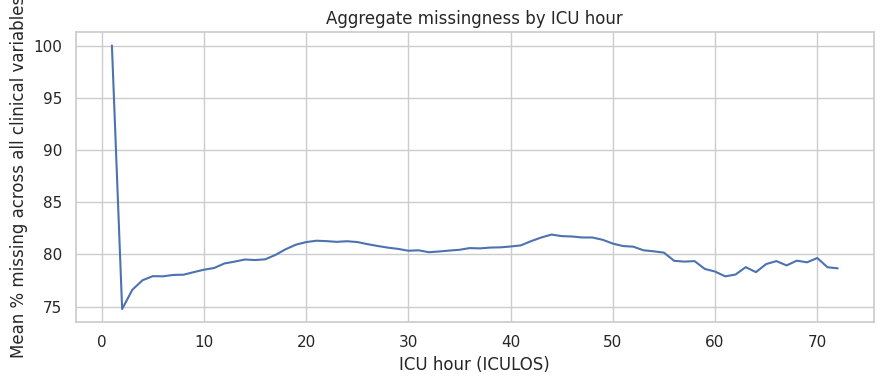

In [6]:
max_hour = 72
hourly = raw_df[raw_df["ICULOS"] <= max_hour]
missing_by_hour = hourly.groupby("ICULOS")[clinical_cols].apply(lambda g: g.isna().mean().mean() * 100)

plt.figure(figsize=(9, 4))
plt.plot(missing_by_hour.index, missing_by_hour.values)
plt.xlabel("ICU hour (ICULOS)")
plt.ylabel("Mean % missing across all clinical variables")
plt.title("Aggregate missingness by ICU hour")
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "04_missingness_by_hour.png", dpi=150)
plt.show()


## 4. Missingness by sepsis status — the key question

**What?** For a focused set of sepsis-relevant labs (Lactate, WBC, Creatinine,
Platelets, Bilirubin_total — all part of common sepsis/organ-dysfunction
screening panels), compare the % measured (i.e. NOT missing) between
sepsis-positive and sepsis-negative patients.

**Why this matters:** If positive patients are measured more often for
these labs, that is itself a usable signal (clinicians order more tests
when they suspect sepsis) — but it also means a naive missing-value
imputation could inadvertently leak label information if done carelessly
(e.g. imputing per-class statistics). This is why Phase 11's imputer is
fit ONLY on training data and never conditioned on the label.


,Lactate,WBC,Creatinine,Platelets,Bilirubin_total
patient_sepsis,,,,,
0.0,2.331642,6.285114,6.002537,5.864546,1.427888
1.0,5.379038,7.380662,6.840090,6.548344,1.994664


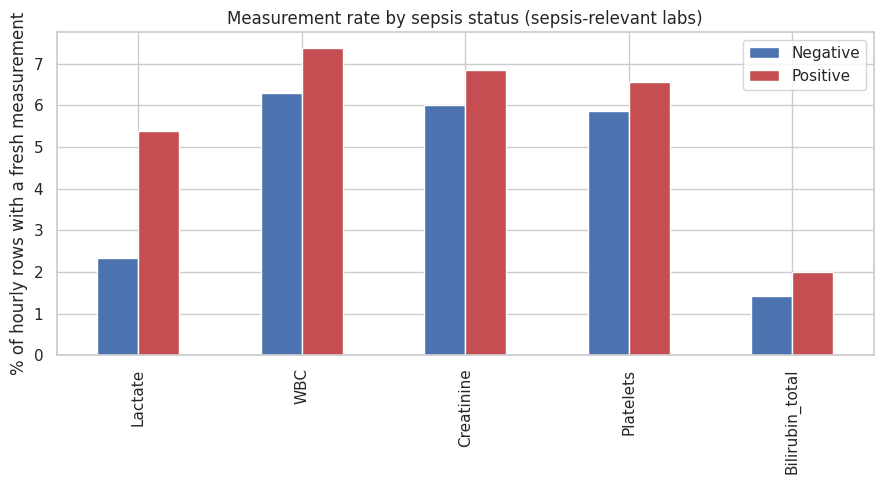

In [7]:
sepsis_relevant_labs = ["Lactate", "WBC", "Creatinine", "Platelets", "Bilirubin_total"]

measured_pct_by_group = (
    raw_df.groupby("patient_sepsis")[sepsis_relevant_labs]
    .apply(lambda g: g.notna().mean() * 100)
)
display(measured_pct_by_group)

measured_pct_by_group.T.plot(kind="bar", figsize=(9, 5), color=["#4C72B0", "#C44E52"])
plt.ylabel("% of hourly rows with a fresh measurement")
plt.title("Measurement rate by sepsis status (sepsis-relevant labs)")
plt.legend(["Negative", "Positive"])
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "04_measurement_rate_by_sepsis_status.png", dpi=150)
plt.show()


## 5. MCAR / MAR / MNAR — definitions (no claim about which applies here)

- **MCAR (Missing Completely At Random):** the probability a value is
  missing does not depend on any observed or unobserved data. Under MCAR,
  dropping or simply imputing missing rows introduces no bias.
- **MAR (Missing At Random):** the probability of missingness depends on
  *observed* data (e.g. other recorded variables, or ICU hour), but not on
  the missing value itself. Imputation conditioned on observed variables
  can be valid under MAR.
- **MNAR (Missing Not At Random):** the probability of missingness depends
  on the *unobserved value itself*, or on unrecorded factors (e.g. a lab is
  not drawn specifically because the clinician already suspects the result
  is abnormal, or because the patient is not sick enough to warrant it).

**What our data suggests (descriptive, not a formal statistical test):**
Section 4 shows measurement rates for sepsis-relevant labs differ by
sepsis status — this is consistent with **MAR at best (depends on observed
clinical severity signals) and plausibly MNAR** for some labs, since
ordering a test is a clinical decision correlated with the patient's true
(possibly still-unmeasured) condition. We explicitly do **not** claim to
have proven MNAR — that would require information beyond this dataset
(e.g. clinician decision logs). This is why missingness indicators are
kept as model inputs (Phase 8) rather than assuming missingness is ignorable.


## 6. Implication for missingness indicators (Phase 8 preview)

Given Section 4's finding, a `<var>_missing_ratio` or `<var>_count` feature
per patient (built in Phase 8) is expected to carry real signal — not
because sicker patients have "more missing data" in a naive sense, but
because clinicians measure sepsis-relevant labs more frequently when they
suspect sepsis. This is documented here so that when such a feature shows
high SHAP importance in Phase 20, it is correctly interpreted as reflecting
clinical decision-making patterns, not a data artifact.


---
### What to send back to Claude after running this notebook

- Section 2's `.describe()` output (per-patient missingness distribution)
- Section 4's measured_pct_by_group table (this is the key result)
- Any visible difference in Section 3's aggregate missingness-by-hour curve

With that, Phase 5 is complete and we move to **Phase 6 (formal Time-Series
Analysis: variability, rate of change)** before the critical **Phase 7
(Target Construction)**.
